<h1 style="color:#b00000;">Wasserrakete: Welcher Füllstand fliegt am höchsten?</h1>

In diesem Notebook modellieren wir einen **senkrechten Start** einer Wasserrakete. Die zentrale Frage lautet:

$$
\boxed{\text{Wie viel Wasser sollte am Anfang in der Flasche sein, damit die Rakete möglichst hoch steigt?}}
$$

Wir beschreiben die Physik Schritt für Schritt und lösen das Modell anschließend mit Python.

<h2 style="color:#b00000;">1. Die Hauptfrage</h2>

Die Flasche hat das Volumen $V_B$. Am Anfang befindet sich das Wasservolumen $V_{w,0}$ in der Flasche. Der **Füllgrad** ist

$$
f=\frac{V_{w,0}}{V_B}.
$$

Gesucht ist der Füllgrad $f^\star$, der die maximale Flughöhe $H_\mathrm{max}$ liefert:

$$
f^\star=\arg\max_{0<f<1} H_\mathrm{max}(f).
$$

Der physikalische Konflikt ist sofort sichtbar:

- wenig Wasser $\Rightarrow$ kleine ausgestoßene Masse,
- viel Wasser $\Rightarrow$ schwere Rakete und wenig Druckluftvolumen.

Deshalb gibt es normalerweise einen optimalen Bereich dazwischen.

<h2 style="color:#b00000;">2. Welche Größen brauchen wir?</h2>

Für einen senkrechten Start beschreiben wir die Bewegung mit der Höhe $z(t)$ und der vertikalen Geschwindigkeit $u(t)$:

$$
\frac{dz}{dt}=u.
$$

Die Beschleunigung folgt aus der Kräftebilanz:

$$
m(t)\frac{du}{dt}=T(t)-m(t)g-D(t).
$$

Dabei ist $T(t)$ der Schub, $m(t)$ die momentane Raketenmasse und $D(t)$ der Luftwiderstand. Damit ist klar, was wir als Nächstes bestimmen müssen:

$$
\boxed{T(t),\quad m(t),\quad D(t)}.
$$

<h2 style="color:#b00000;">3. Die Masse der Rakete</h2>

Die Rakete besteht aus einer trockenen Masse $m_\mathrm{dry}$ und dem Wasser in der Flasche:

$$
m(t)=m_\mathrm{dry}+\rho_w V_w(t).
$$

Hier ist $\rho_w$ die Dichte von Wasser und $V_w(t)$ das verbleibende Wasservolumen.

Wenn Wasser durch die Düse austritt, nimmt $V_w(t)$ ab:

$$
\frac{dV_w}{dt}=-A_e v_e.
$$

Dabei ist $A_e$ die Düsenfläche und $v_e$ die Austrittsgeschwindigkeit des Wassers relativ zur Rakete.

<h2 style="color:#b00000;">4. Woher kommt der Schub?</h2>

Der Schub entsteht, weil Wasser nach unten ausgestoßen wird. Für den Massenstrom gilt

$$
\dot m_w=\rho_w A_e v_e.
$$

Der Schub ist Impulsstrom:

$$
T=\dot m_w v_e.
$$

Damit folgt

$$
\boxed{T=\rho_w A_e v_e^2}.
$$

Jetzt ist das nächste Ziel eindeutig: Wir müssen $v_e(t)$ bestimmen.

<h2 style="color:#b00000;">5. Wie schnell verlässt das Wasser die Düse?</h2>

Die Austrittsgeschwindigkeit kommt aus einer Bernoulli-Bilanz zwischen der Wasseroberfläche in der Flasche und der Düsenöffnung. In vereinfachter Form erhalten wir

$$
v_e=C_v\sqrt{\frac{2\left(p_a-p_\infty+\rho_w g h_w\right)}{\rho_w\left[1-\left(A_e/A_B\right)^2\right]}}.
$$

Dabei ist:

- $p_a(t)$ der Luftdruck in der Flasche,
- $p_\infty$ der Umgebungsdruck,
- $h_w(t)$ die Wasserhöhe über der Düse,
- $A_B$ die effektive Querschnittsfläche der Flasche,
- $C_v$ ein einfacher Verlustfaktor der Düse.

Wenn $A_B\gg A_e$ ist, dann ist $1-(A_e/A_B)^2\approx 1$. Der wichtigste Anteil ist dann die Druckdifferenz $p_a-p_\infty$.

<div style="border-left: 6px solid #b00000; background-color: #fff3f3; padding: 12px;">
<b>Wichtiger Punkt: absoluter Druck vs. Manometerdruck</b><br>
Ein Manometer zeigt meistens den Druck relativ zur Umgebung an. Wenn das Manometer $5\,\mathrm{bar}$ anzeigt, dann ist das der Manometerdruck $p_\mathrm{gauge}$. Für die Gasgleichung brauchen wir aber den absoluten Druck:

$$
p_{a,0}=p_\infty+p_\mathrm{gauge,0}.
$$

Für den Wasseraustritt ist dagegen die Druckdifferenz $p_a-p_\infty$ entscheidend.
</div>

<h2 style="color:#b00000;">6. Wie ändert sich der Druck in der Flasche?</h2>

Während Wasser austritt, wächst das Luftvolumen in der Flasche:

$$
V_a(t)=V_B-V_w(t).
$$

Die eingeschlossene Luft expandiert. Für einen schnellen Start ist eine isentrope Näherung sinnvoll:

$$
p_a(t)V_a(t)^n=p_{a,0}V_{a,0}^n.
$$

Damit folgt

$$
p_a(t)=p_{a,0}\left(\frac{V_{a,0}}{V_a(t)}\right)^n.
$$

Für Luft verwenden wir hier standardmäßig $n=1.4$. Zum Vergleich: $n=1$ wäre eine isotherme Näherung.

<h2 style="color:#b00000;">7. Das geschlossene Modell</h2>

Unsere Zustandsgrößen sind

$$
y(t)=\left(z(t),u(t),V_w(t)\right).
$$

Das Modell lautet

$$
\frac{dz}{dt}=u,
$$

$$
\frac{du}{dt}=\frac{T-mg-D}{m},
$$

$$
\frac{dV_w}{dt}=-A_e v_e.
$$

Zusätzlich verwenden wir

$$
m=m_\mathrm{dry}+\rho_w V_w,
$$

$$
T=\rho_w A_e v_e^2,
$$

$$
D=\frac{1}{2}\rho_\infty C_D A_\mathrm{ref} u|u|.
$$

Nach dem Wasserausstoß setzen wir $T=0$ und $dV_w/dt=0$. Dann steigt die Rakete nur noch aufgrund ihrer Geschwindigkeit weiter, bis $u=0$ erreicht ist. Dieser Punkt ist die maximale Höhe.

<h2 style="color:#b00000;">8. Python-Modell</h2>

Jetzt übersetzen wir das Modell in Python. Alle Größen werden in SI-Einheiten verwendet: Meter, Kilogramm, Sekunden und Pascal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.integrate import solve_ivp

@dataclass
class RocketParameters:
    # Geometrie
    V_bottle: float = 1.5e-3          # Flaschenvolumen [m^3], 1.5 Liter
    bottle_length: float = 0.32       # effektive Flaschenlänge [m]
    nozzle_diameter: float = 9.0e-3   # Düsendurchmesser [m]
    body_diameter: float = 0.09       # Raketen-/Flaschendurchmesser [m]

    # Masse und Druck
    m_dry: float = 0.160              # trockene Masse [kg]
    p_gauge0: float = 5.0e5           # Anfangs-Manometerdruck [Pa], 5 bar
    p_inf: float = 101_325.0          # Umgebungsdruck [Pa]

    # Stoffwerte und Modellparameter
    rho_w: float = 1000.0             # Wasserdichte [kg/m^3]
    rho_air: float = 1.20             # Luftdichte außen [kg/m^3]
    g: float = 9.81                   # Erdbeschleunigung [m/s^2]
    C_D: float = 0.45                 # Widerstandsbeiwert der Rakete [-]
    C_v: float = 0.95                 # Düsen-Geschwindigkeitsfaktor [-]
    n_expansion: float = 1.4          # 1.4 isentrop, 1.0 isotherm
    include_drag: bool = True         # Luftwiderstand ein-/ausschalten
    use_unsteady_bernoulli: bool = False  # True: v_e als eigene DGL lösen
    L_e: float = 0.02                 # effektive Düsenlänge für unsteady Bernoulli [m]

    @property
    def A_nozzle(self):
        return np.pi * (self.nozzle_diameter / 2.0)**2

    @property
    def A_bottle(self):
        return self.V_bottle / self.bottle_length

    @property
    def A_ref(self):
        return np.pi * (self.body_diameter / 2.0)**2

    @property
    def p0_abs(self):
        return self.p_inf + self.p_gauge0

In [2]:
def simulate_fill_fraction(f, par=None, t_max=12.0, max_step=0.01):
    """Simulates a vertical water rocket launch for one filling fraction f."""
    if par is None:
        par = RocketParameters()
    if not (0.0 < f < 0.98):
        raise ValueError("f must be between 0 and 0.98.")

    Vw0 = f * par.V_bottle
    Va0 = par.V_bottle - Vw0
    A2 = par.A_nozzle
    A1 = par.A_bottle
    beta = A2 / A1
    area_factor = max(1e-12, 1.0 - beta**2)

    def pressure_abs(Vw):
        Vw = np.clip(Vw, 0.0, 0.999 * par.V_bottle)
        Va = par.V_bottle - Vw
        return par.p0_abs * (Va0 / Va)**par.n_expansion

    def driving_head(Vw):
        if Vw <= 1e-10:
            return 0.0

        pa = pressure_abs(Vw)
        h_w = Vw / A1
        return (pa - par.p_inf) / par.rho_w + par.g * h_w

    def exhaust_velocity(Vw):
        head = driving_head(Vw)

        if head <= 0.0:
            return 0.0

        return par.C_v * np.sqrt(2.0 * head / area_factor)

    def unsteady_exhaust_acceleration(Vw, ve):
        if Vw <= 1e-10:
            return 0.0

        h_w = Vw / A1
        inertia_length = max(1e-9, par.L_e + beta * h_w)
        head = driving_head(Vw)

        # Keep C_v in the kinetic term so the steady limit matches exhaust_velocity().
        loss_factor = max(1e-9, par.C_v)
        kinetic_head = 0.5 * area_factor * (max(0.0, ve) / loss_factor)**2
        dve_dt = (head - kinetic_head) / inertia_length

        if ve <= 0.0 and dve_dt < 0.0:
            return 0.0
        return dve_dt

    def rhs(t, y):
        if par.use_unsteady_bernoulli:
            z, u, Vw, ve_state = y
        else:
            z, u, Vw = y
            ve_state = None

        Vw_eff = max(0.0, min(Vw, Vw0))

        if par.use_unsteady_bernoulli:
            ve = max(0.0, ve_state)
            if Vw_eff <= 1e-10:
                ve = 0.0
        else:
            ve = exhaust_velocity(Vw_eff)

        thrust = par.rho_w * A2 * ve**2

        if Vw_eff <= 1e-10 or ve <= 0.0:
            dVw_dt = 0.0
            if Vw <= 1e-10:
                Vw_eff = 0.0
        else:
            dVw_dt = -A2 * ve

        mass = par.m_dry + par.rho_w * Vw_eff

        if par.include_drag:
            drag = 0.5 * par.rho_air * par.C_D * par.A_ref * u * abs(u)
        else:
            drag = 0.0

        dz_dt = u
        du_dt = (thrust - mass * par.g - drag) / mass

        if par.use_unsteady_bernoulli:
            dve_dt = unsteady_exhaust_acceleration(Vw_eff, ve)
            return [dz_dt, du_dt, dVw_dt, dve_dt]

        return [dz_dt, du_dt, dVw_dt]

    def apex_event(t, y):
        # Avoid detecting the initial condition u=0 as the maximum height.
        if t < 0.05:
            return 1.0
        return y[1]

    apex_event.terminal = True
    apex_event.direction = -1

    initial_state = [0.0, 0.0, Vw0]
    atol = [1e-8, 1e-8, 1e-10]
    if par.use_unsteady_bernoulli:
        initial_state.append(0.0)
        atol.append(1e-8)

    sol = solve_ivp(
        rhs,
        (0.0, t_max),
        initial_state,
        max_step=max_step,
        rtol=1e-7,
        atol=atol,
        events=apex_event,
    )

    t = sol.t

    if par.use_unsteady_bernoulli:
        z, u, Vw, ve_state = sol.y
        Vw = np.maximum(Vw, 0.0)
        ve = np.maximum(ve_state, 0.0)
        ve[Vw <= 1e-8] = 0.0
    else:
        z, u, Vw = sol.y
        Vw = np.maximum(Vw, 0.0)
        ve = np.array([exhaust_velocity(v) for v in Vw])

    thrust = par.rho_w * par.A_nozzle * ve**2
    p_abs = np.array([pressure_abs(v) if v > 1e-10 else np.nan for v in Vw])

    active = (Vw > 1e-8) & (thrust > 1e-8)
    t_burnout = float(t[np.where(active)[0][-1]]) if np.any(active) else 0.0

    return {
        "f": f,
        "t": t,
        "z": z,
        "u": u,
        "Vw": Vw,
        "ve": ve,
        "thrust": thrust,
        "p_abs": p_abs,
        "Hmax": float(np.max(z)),
        "t_burnout": t_burnout,
        "model": "unsteady Bernoulli" if par.use_unsteady_bernoulli else "quasi-steady Bernoulli",
        "success": sol.success,
        "message": sol.message,
        "par": par,
    }

<h2 style="color:#b00000;">9. Parameter einstellen</h2>

In der nächsten Codezelle stehen die Werte, die du für eigene Rechnungen ändern kannst. Die Modellfunktionen darunter verwenden anschließend genau diese Werte. Setze `use_unsteady_bernoulli=True`, wenn die Austrittsgeschwindigkeit als eigene Differentialgleichung berechnet werden soll.

In [ ]:
# Parameter, die du für die Rechnung ändern kannst.
par = RocketParameters(
    V_bottle=1.5e-3,               # Flaschenvolumen [m^3], 1.5 Liter
    bottle_length=0.32,            # effektive Flaschenlänge [m]
    nozzle_diameter=9.0e-3,        # Düsendurchmesser [m]
    body_diameter=0.09,            # Raketen-/Flaschendurchmesser [m]
    m_dry=0.160,                   # trockene Masse [kg]
    p_gauge0=5.0e5,                # Anfangs-Manometerdruck [Pa], 5 bar
    p_inf=101_325.0,               # Umgebungsdruck [Pa]
    rho_w=1000.0,                  # Wasserdichte [kg/m^3]
    rho_air=1.20,                  # Luftdichte außen [kg/m^3]
    g=9.81,                        # Erdbeschleunigung [m/s^2]
    C_D=0.45,                      # Widerstandsbeiwert der Rakete [-]
    C_v=0.95,                      # Düsen-Geschwindigkeitsfaktor [-]
    n_expansion=1.4,               # 1.4 isentrop, 1.0 isotherm
    include_drag=True,             # Luftwiderstand ein-/ausschalten
    use_unsteady_bernoulli=False,  # True: v_e als eigene DGL lösen
    L_e=0.02,                      # effektive Düsenlänge für unsteady Bernoulli [m]
)

fill_fraction = 0.40               # Füllgrad für die Beispielrechnung [-]

<h2 style="color:#b00000;">10. Eine Beispielrechnung</h2>

Wir rechnen zuerst den in der Parameterzelle gewählten Füllgrad. Danach suchen wir automatisch das Optimum.

In [3]:
result = simulate_fill_fraction(fill_fraction, par)

print(f"Füllgrad: {100*result['f']:.1f} %")
print(f"Maximale Höhe: {result['Hmax']:.2f} m")
print(f"Dauer des Wasserausstoßes: {result['t_burnout']:.3f} s")
print(f"Maximale Geschwindigkeit: {np.max(result['u']):.2f} m/s")

Füllgrad: 40.0 %
Maximale Höhe: 37.55 m
Dauer des Wasserausstoßes: 0.406 s
Maximale Geschwindigkeit: 30.07 m/s


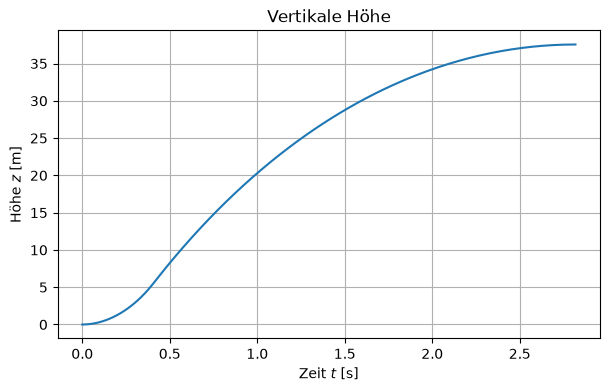

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(result["t"], result["z"])
plt.xlabel("Zeit $t$ [s]")
plt.ylabel("Höhe $z$ [m]")
plt.title("Vertikale Höhe")
plt.grid(True)
plt.show()

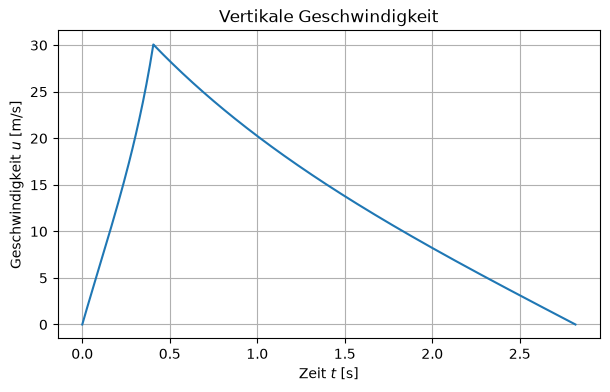

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(result["t"], result["u"])
plt.xlabel("Zeit $t$ [s]")
plt.ylabel("Geschwindigkeit $u$ [m/s]")
plt.title("Vertikale Geschwindigkeit")
plt.grid(True)
plt.show()

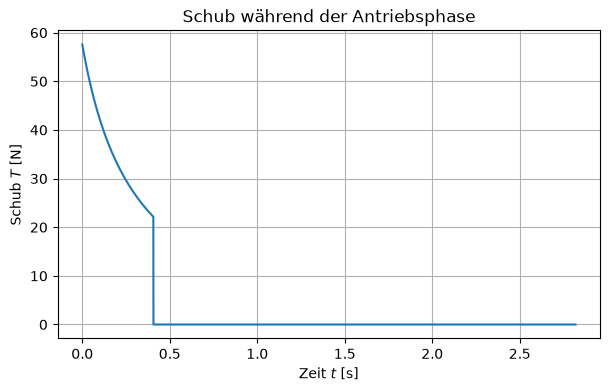

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(result["t"], result["thrust"])
plt.xlabel("Zeit $t$ [s]")
plt.ylabel("Schub $T$ [N]")
plt.title("Schub während der Antriebsphase")
plt.grid(True)
plt.show()

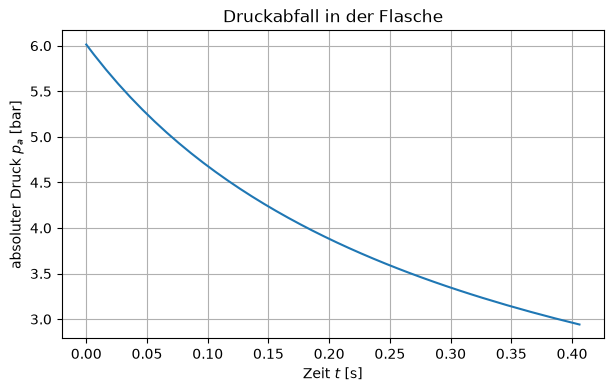

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(result["t"], result["p_abs"] / 1e5)
plt.xlabel("Zeit $t$ [s]")
plt.ylabel("absoluter Druck $p_a$ [bar]")
plt.title("Druckabfall in der Flasche")
plt.grid(True)
plt.show()

<h2 style="color:#b00000;">11. Suche nach dem optimalen Füllgrad</h2>

Jetzt berechnen wir $H_\mathrm{max}(f)$ für viele Füllgrade. Der beste Füllgrad ist der Punkt, an dem die Kurve ihr Maximum hat.

In [8]:
f_values = np.linspace(0.05, 0.85, 81)
heights = np.array([simulate_fill_fraction(f, par)["Hmax"] for f in f_values])

best_index = np.argmax(heights)
f_best = f_values[best_index]
H_best = heights[best_index]

print(f"Optimaler Füllgrad: {100*f_best:.1f} %")
print(f"Maximale Höhe beim Optimum: {H_best:.2f} m")

Optimaler Füllgrad: 40.0 %
Maximale Höhe beim Optimum: 37.55 m


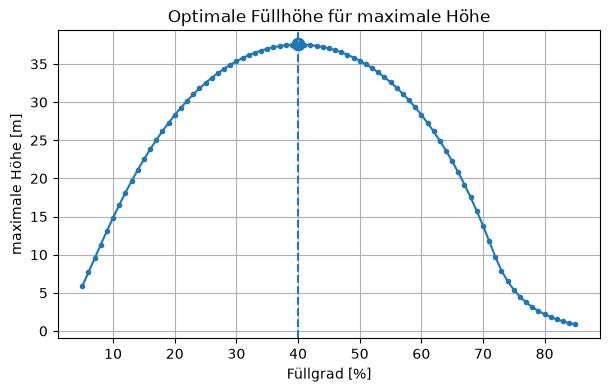

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(100 * f_values, heights, marker="o", markersize=3)
plt.scatter([100 * f_best], [H_best], s=80)
plt.axvline(100 * f_best, linestyle="--")
plt.xlabel("Füllgrad [%]")
plt.ylabel("maximale Höhe [m]")
plt.title("Optimale Füllhöhe für maximale Höhe")
plt.grid(True)
plt.show()


<h2 style="color:#b00000;">12. Warum gibt es ein Optimum?</h2>

Die Kurve hat ein Maximum, weil zwei Effekte gegeneinander arbeiten:

- Bei kleinem $f$ ist viel Druckluft vorhanden, aber nur wenig Wasser als Reaktionsmasse.
- Bei großem $f$ ist viel Wasser vorhanden, aber die Rakete ist schwer und das Anfangsvolumen der Druckluft ist klein.

Das Optimum entsteht dort, wo diese beiden Effekte am besten ausbalanciert sind.

<h2 style="color:#b00000;">13. Kleine Experimente im Notebook</h2>

Ändere in der Parameter-Zelle oben zum Beispiel:

- den Manometerdruck $p_\mathrm{gauge,0}$,
- den Düsendurchmesser $d_e$,
- die trockene Masse $m_\mathrm{dry}$,
- den Exponenten $n$ der Gasexpansion,
- den Luftwiderstand über `include_drag`.
- das Bernoulli-Modell über `use_unsteady_bernoulli` und `L_e`.

Beobachte danach, wie sich $f^\star$ und $H_\mathrm{max}$ verändern.

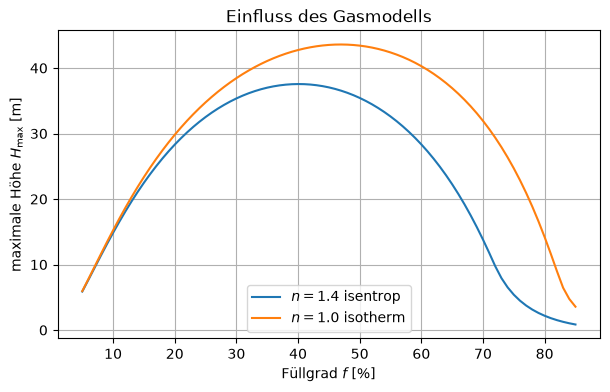

In [10]:
# Beispiel: Vergleich zwischen isentroper und isothermer Expansion
par_isentropic = RocketParameters(n_expansion=1.4)
par_isothermal = RocketParameters(n_expansion=1.0)

heights_isentropic = np.array([
    simulate_fill_fraction(f, par_isentropic)["Hmax"] for f in f_values
])
heights_isothermal = np.array([
    simulate_fill_fraction(f, par_isothermal)["Hmax"] for f in f_values
])

plt.figure(figsize=(7, 4))
plt.plot(100 * f_values, heights_isentropic, label="$n=1.4$ isentrop")
plt.plot(100 * f_values, heights_isothermal, label="$n=1.0$ isotherm")
plt.xlabel("Füllgrad $f$ [%]")
plt.ylabel(r"maximale Höhe $H_\mathrm{max}$ [m]")
plt.title("Einfluss des Gasmodells")
plt.legend()
plt.grid(True)
plt.show()

<h2 style="color:#b00000;">14. Zusammenfassung</h2>

Für den senkrechten Start haben wir die Frage

$$
f^\star=\arg\max_{0<f<1} H_\mathrm{max}(f)
$$

in ein berechenbares Modell übersetzt. Die wichtigste Modellkette ist

$$
\boxed{f \rightarrow V_{w,0} \rightarrow V_a(t) \rightarrow p_a(t) \rightarrow v_e(t) \rightarrow T(t) \rightarrow z(t) \rightarrow H_\mathrm{max}}.
$$

Damit entsteht eine klare Modellkette von der physikalischen Idee bis zur numerischen Optimierung.

<div style="border-left: 6px solid #b00000; background-color: #fff3f3; padding: 12px; margin-top: 12px;">
<b>Sicherheit:</b> Reale Wasserraketen dürfen nur mit geeigneter Abschussvorrichtung, Abstand, Schutzbrille und unter Aufsicht gestartet werden.
</div>